In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.stats import sem

np.random.seed(42)

# -------------------------
# Experimental design
# -------------------------
models = ["small_transformer", "large_transformer"]
directions = ["forward", "backward"]
chunk_conditions = ["chunked", "unchunked"]
sequence_lengths = np.arange(3, 16)
n_trials = 100

rows = []

# -------------------------
# Simulated accuracy model
# -------------------------
for model in models:
    for direction in directions:
        for chunking in chunk_conditions:
            for length in sequence_lengths:
                for trial in range(n_trials):

                    # baseline ability
                    ability = 2.8 if model == "large_transformer" else 2.1

                    # longer sequences are harder
                    length_cost = -0.38 * length

                    # backward recall is harder
                    backward_cost = -0.8 if direction == "backward" else 0

                    # chunking benefit
                    chunk_bonus = 1.0 if chunking == "chunked" else 0

                    # larger models benefit more from chunks
                    if model == "large_transformer" and chunking == "chunked":
                        chunk_bonus += 0.4

                    # chunking helps more at longer lengths
                    if chunking == "chunked":
                        chunk_bonus += 0.08 * length

                    # noise
                    noise = np.random.normal(0, 0.5)

                    logit_p = ability + length_cost + backward_cost + chunk_bonus + noise
                    p_correct = expit(logit_p)

                    correct = np.random.binomial(1, p_correct)

                    rows.append({
                        "model": model,
                        "direction": direction,
                        "chunking": chunking,
                        "length": length,
                        "trial": trial,
                        "p_correct": p_correct,
                        "correct": correct
                    })

df = pd.DataFrame(rows)
df.head()

,model,direction,chunking,length,trial,p_correct,correct
0,small_transformer,forward,chunked,3,0,0.920441,1
1,small_transformer,forward,chunked,3,1,0.893867,1
2,small_transformer,forward,chunked,3,2,0.889232,1
3,small_transformer,forward,chunked,3,3,0.889233,1
4,small_transformer,forward,chunked,3,4,0.952102,1


In [2]:
# -------------------------
# Aggregate results
# -------------------------
summary = (
    df.groupby(["model", "direction", "chunking", "length"])
      .agg(
          mean_accuracy=("correct", "mean"),
          se_accuracy=("correct", sem)
      )
      .reset_index()
)

summary["percent_accuracy"] = summary["mean_accuracy"] * 100
summary["se_percent"] = summary["se_accuracy"] * 100

summary.head()

,model,direction,chunking,length,mean_accuracy,se_accuracy,percent_accuracy,se_percent
0,large_transformer,backward,chunked,3,0.90,0.030151,90.0,3.015113
1,large_transformer,backward,chunked,4,0.92,0.027266,92.0,2.726599
2,large_transformer,backward,chunked,5,0.92,0.027266,92.0,2.726599
3,large_transformer,backward,chunked,6,0.83,0.037753,83.0,3.775252
4,large_transformer,backward,chunked,7,0.66,0.047610,66.0,4.760952


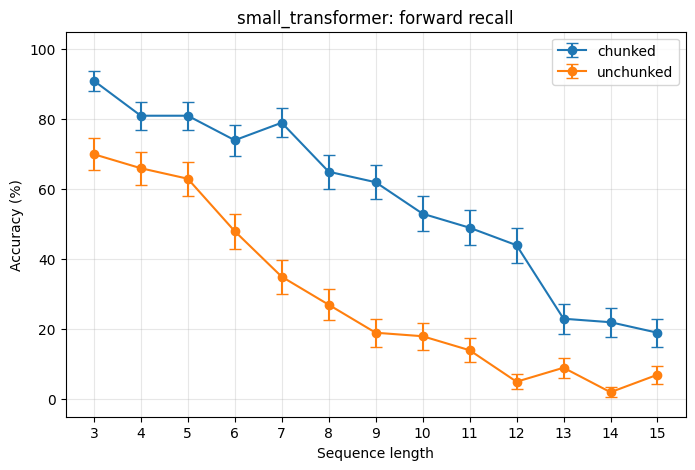

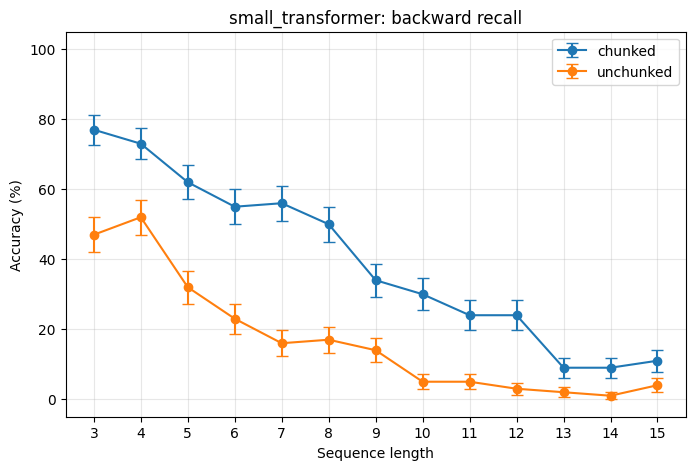

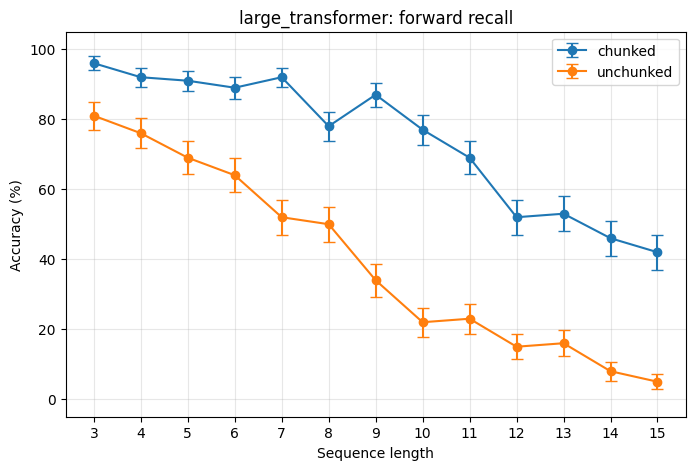

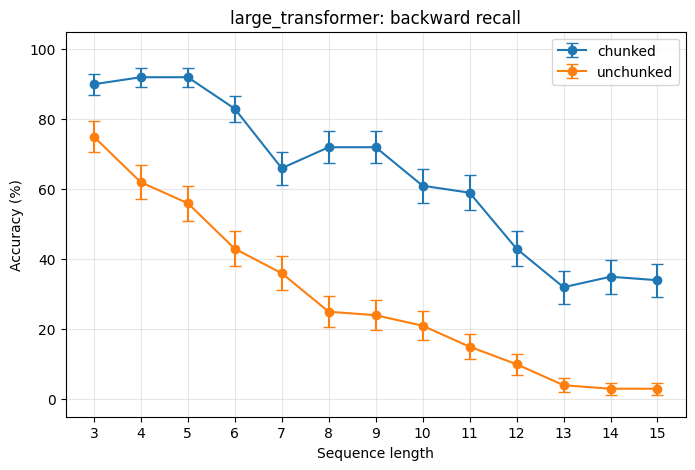

In [3]:
# -------------------------
# Plot results
# -------------------------
for model in models:
    for direction in directions:
        plt.figure(figsize=(8, 5))

        for chunking in chunk_conditions:
            sub = summary[
                (summary["model"] == model) &
                (summary["direction"] == direction) &
                (summary["chunking"] == chunking)
            ]

            plt.errorbar(
                sub["length"],
                sub["percent_accuracy"],
                yerr=sub["se_percent"],
                marker="o",
                capsize=4,
                label=chunking
            )

        plt.title(f"{model}: {direction} recall")
        plt.xlabel("Sequence length")
        plt.ylabel("Accuracy (%)")
        plt.ylim(-5, 105)
        plt.xticks(sequence_lengths)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

In [4]:
# -------------------------
# Estimate chunking benefit
# -------------------------
chunk_effect = (
    summary.pivot_table(
        index=["model", "direction", "length"],
        columns="chunking",
        values="percent_accuracy"
    )
    .reset_index()
)

chunk_effect["chunking_benefit"] = (
    chunk_effect["chunked"] - chunk_effect["unchunked"]
)

chunk_effect.head()

chunking,model,direction,length,chunked,unchunked,chunking_benefit
0,large_transformer,backward,3,90.0,75.0,15.0
1,large_transformer,backward,4,92.0,62.0,30.0
2,large_transformer,backward,5,92.0,56.0,36.0
3,large_transformer,backward,6,83.0,43.0,40.0
4,large_transformer,backward,7,66.0,36.0,30.0


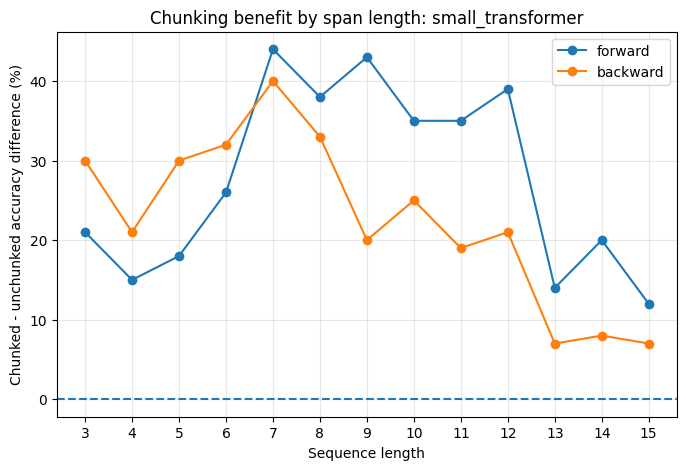

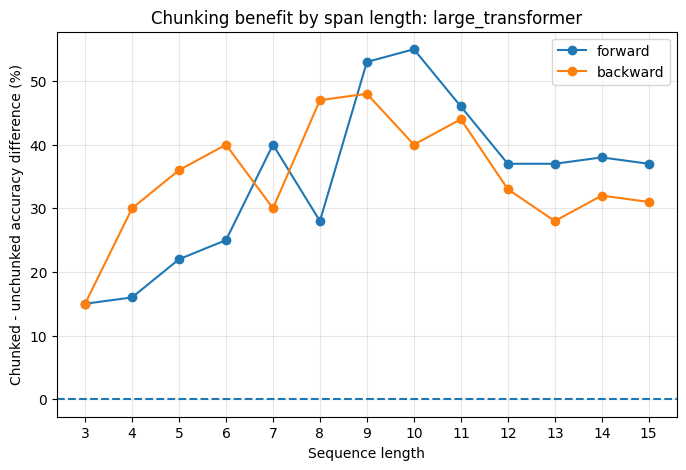

In [6]:
# -------------------------
# Plot chunking benefit directly
# -------------------------
for model in models:
    plt.figure(figsize=(8, 5))

    for direction in directions:
        sub = chunk_effect[
            (chunk_effect["model"] == model) &
            (chunk_effect["direction"] == direction)
        ]

        plt.plot(
            sub["length"],
            sub["chunking_benefit"],
            marker="o",
            label=direction
        )

    plt.axhline(0, linestyle="--")
    plt.title(f"Chunking benefit by span length: {model}")
    plt.xlabel("Sequence length")
    plt.ylabel("Chunked - unchunked accuracy difference (%)")
    plt.xticks(sequence_lengths)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()